In [28]:
from google.colab import files
uploaded=files.upload()

Saving netflix_titles.csv to netflix_titles (1).csv


In [29]:
# STEP 1 - load and inspect data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
plt.rcParams['figure.facecolor'] = 'white'

df = pd.read_csv('netflix_titles.csv')
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [31]:
print("Data types:\n")
print(df.dtypes)

Data types:

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [32]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


In [33]:
dup_count = df.duplicated().sum()
dup_id_count = df.duplicated(subset=['title', 'type', 'release_year']).sum()
print(f"Fully duplicated rows: {dup_count}")
print(f"Duplicate (title, type, release_year) combinations: {dup_id_count}")

Fully duplicated rows: 0
Duplicate (title, type, release_year) combinations: 0


**Summary**

1. he dataset has 8,807 titles across 12 columns, covering both Movies and TV Shows available on Netflix.
2. Each row describes one title's metadata: type, title, director, cast, country, date added to Netflix, release year, rating, duration, genre(s), and description.
3. Several columns have significant missing values — director (~ 30%), cast (~ 9%), and country (~9%) are the most affected, while date_added, rating, and duration have only a handful of missing values.
4. There are no fully duplicated rows, so the dataset does not need de-duplication at the row level.
5. Columns are stored as generic object/int64 types out of the box — date_added needs conversion to a real datetime, and duration needs to be split into a numeric field since it mixes "minutes" (Movies) with "Seasons" (TV Shows).

In [34]:
# STEP 2 - Clean the data

df_clean = df.copy()
print("Starting shape:", df_clean.shape)
for col in ['director', 'cast', 'country']:
  df_clean[col] = df_clean[col].fillna('Unknown')
  print("Remaining nulls in director/cast/country:")
  print(df_clean[['director', 'cast', 'country']].isnull().sum())
before = len(df_clean)

df_clean = df_clean.dropna(subset=['date_added', 'rating', 'duration'])
after = len(df_clean)
print(f"Dropped {before - after} rows with missing date_added/rating/duration ({(before-after)/before*100:.2f}% of data)")
print("New shape:", df_clean.shape)

df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), format='%B %d, %Y')
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month
df_clean[['date_added', 'year_added', 'month_added']].head()

df_clean['duration_minutes'] = df_clean.loc[df_clean['type'] == 'Movie', 'duration'].str.extract(r'(\d+)').astype(float)
df_clean['duration_seasons'] = df_clean.loc[df_clean['type'] == 'TV Show', 'duration'].str.extract(r'(\d+)').astype(float)
df_clean[['type', 'duration', 'duration_minutes', 'duration_seasons']].sample(6, random_state=1)

df_clean = df_clean.drop(columns=['show_id', 'description'])
print("Columns remaining:", list(df_clean.columns))

Starting shape: (8807, 12)
Remaining nulls in director/cast/country:
director      0
cast        825
country     831
dtype: int64
Remaining nulls in director/cast/country:
director      0
cast          0
country     831
dtype: int64
Remaining nulls in director/cast/country:
director    0
cast        0
country     0
dtype: int64
Dropped 17 rows with missing date_added/rating/duration (0.19% of data)
New shape: (8790, 12)
Columns remaining: ['type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'year_added', 'month_added', 'duration_minutes', 'duration_seasons']


**STEP 3 - Exploratory Data Analysis(EDA)**

Answer 5 specific questions about the data using groupby, value_counts, describe, and other Pandas methods. Each question must have a code output.

Below






In [35]:
# Q1

type_counts = df_clean['type'].value_counts()
type_pct = df_clean['type'].value_counts(normalize=True).mul(100).round(1)
pd.DataFrame({'count': type_counts, 'percent': type_pct})

,count,percent
type,,
Movie,6126,69.7
TV Show,2664,30.3


In [36]:
# Q2

countries_exploded = df_clean.assign(country=df_clean['country'].str.split(', ')).explode('country')
top_countries = countries_exploded[countries_exploded['country'] != 'Unknown']['country'].value_counts().head(10)
top_countries

,count
country,
United States,3680
India,1046
United Kingdom,803
Canada,445
France,393
Japan,316
Spain,232
South Korea,231
Germany,226


In [37]:
# Q3

titles_per_year = df_clean.groupby('year_added').size()
titles_per_year

,0
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,426


In [38]:
# Q4

genres_exploded = df_clean.assign(listed_in=df_clean['listed_in'].str.split(', ')).explode('listed_in')
top_genres = genres_exploded['listed_in'].value_counts().head(10)
top_genres

,count
listed_in,
International Movies,2752
Dramas,2426
Comedies,1674
International TV Shows,1349
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


In [39]:
# Q5

print("Movie duration (minutes) — summary statistics:")
print(df_clean['duration_minutes'].describe())
print("\nTV Show length (seasons) — summary statistics:")
print(df_clean['duration_seasons'].describe())

Movie duration (minutes) — summary statistics:
count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

TV Show length (seasons) — summary statistics:
count    2664.000000
mean        1.751877
std         1.550622
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_seasons, dtype: float64


**Step 4 — Visualizations with 6 Charts**

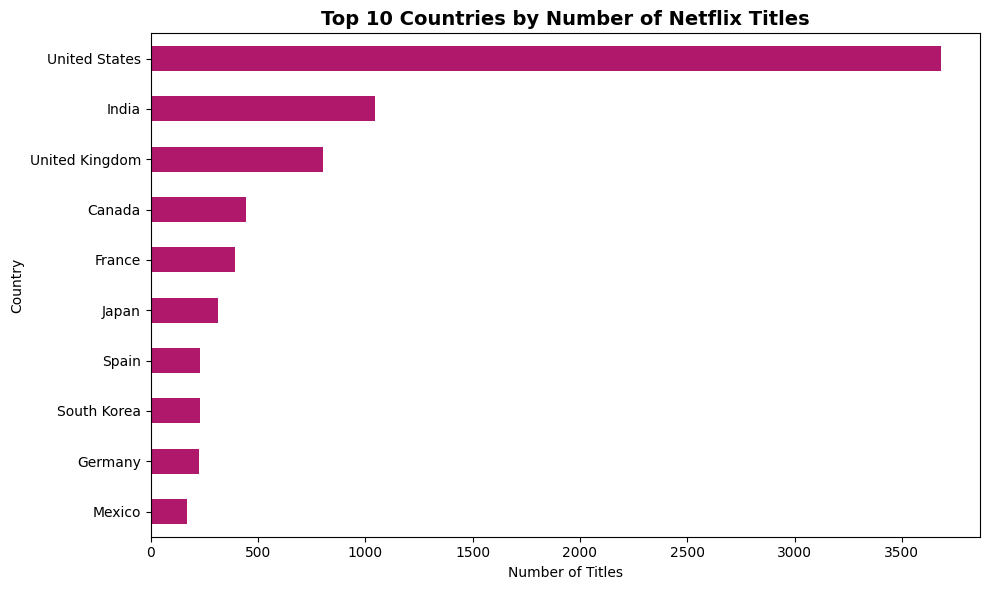

In [40]:
# Chart 1 — Bar chart: Top 10 content-producing countries

fig, ax = plt.subplots(figsize=(10, 6))
top_countries.sort_values().plot(kind='barh', ax=ax, color='#B0186C')
ax.set_title('Top 10 Countries by Number of Netflix Titles', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

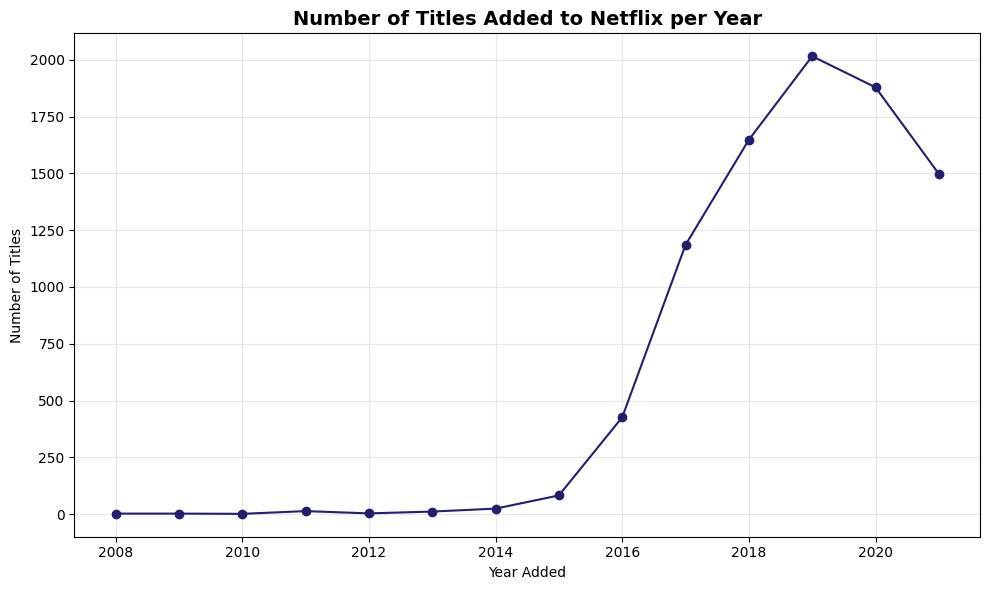

In [41]:
# Chart 2 — Line chart: Titles added to Netflix per year

fig, ax = plt.subplots(figsize=(10, 6))
titles_per_year.plot(kind='line', marker='o', ax=ax, color='#221F6F')
ax.set_title('Number of Titles Added to Netflix per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

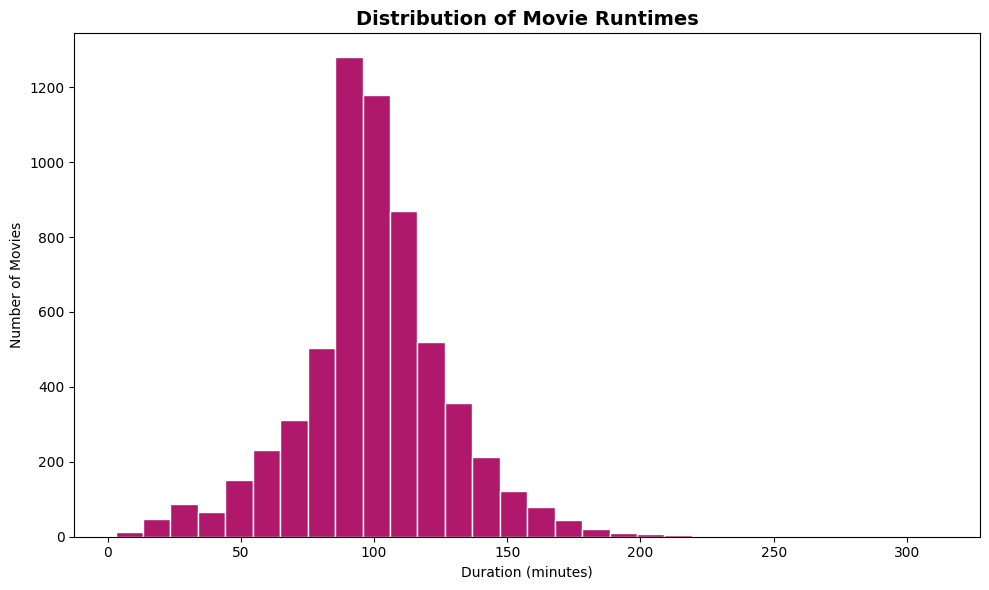

In [42]:
# Chart 3 — Histogram: Distribution of Movie runtimes

fig, ax = plt.subplots(figsize=(10, 6))
df_clean['duration_minutes'].dropna().plot(kind='hist', bins=30, ax=ax, color='#B0186C', edgecolor='white')
ax.set_title('Distribution of Movie Runtimes', fontsize=14, fontweight='bold')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Movies')
plt.tight_layout()
plt.show()

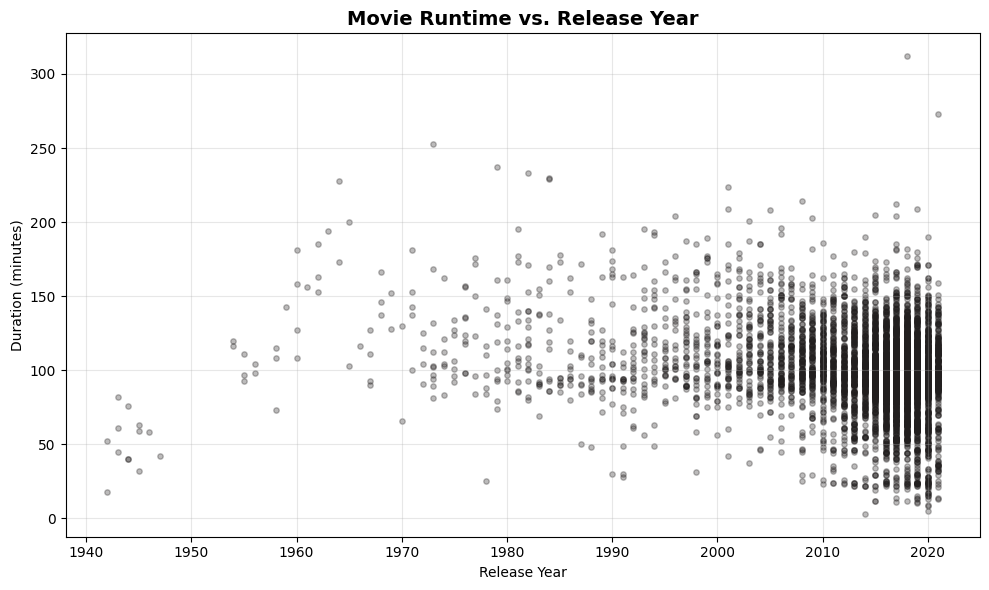

In [43]:
# Chart 4 — Scatter plot: Release year vs. Movie runtime

movies = df_clean[df_clean['type'] == 'Movie'].dropna(subset=['duration_minutes'])
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(movies['release_year'], movies['duration_minutes'], alpha=0.3, s=15, color='#221F1F')
ax.set_title('Movie Runtime vs. Release Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Duration (minutes)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

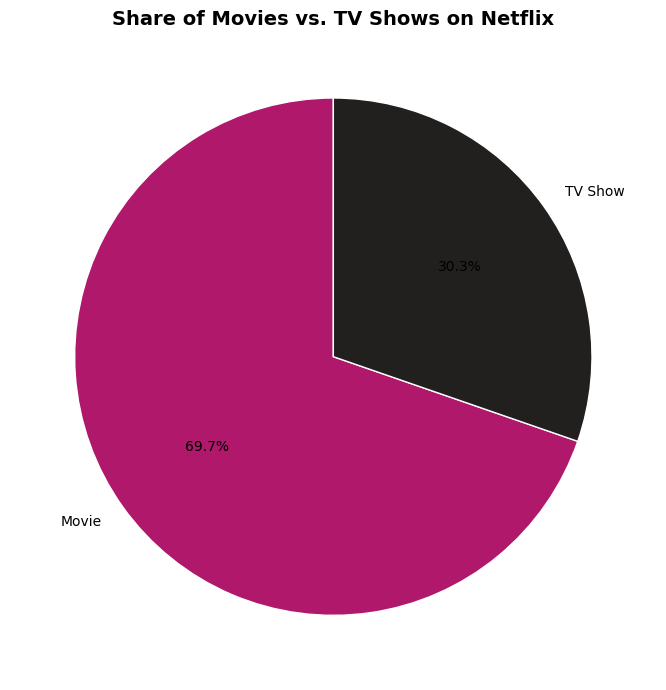

In [44]:
#Chart 5 — Pie chart: Movies vs. TV Shows

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
       colors=['#B0186C', '#221F1F'], startangle=90, wedgeprops={'edgecolor': 'white'})
ax.set_title('Share of Movies vs. TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

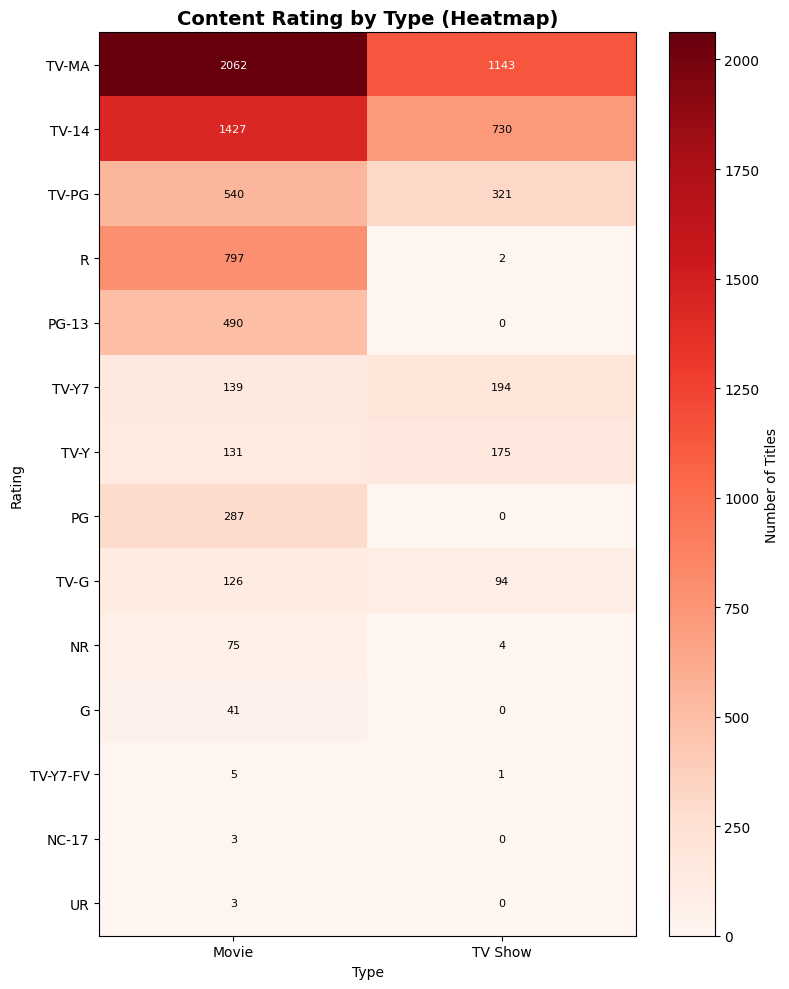

In [45]:
# Chart 6 — Heatmap: Content rating by type

rating_type = pd.crosstab(df_clean['rating'], df_clean['type'])
rating_type = rating_type.loc[rating_type.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(rating_type.values, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(rating_type.columns)))
ax.set_xticklabels(rating_type.columns)
ax.set_yticks(range(len(rating_type.index)))
ax.set_yticklabels(rating_type.index)
ax.set_title('Content Rating by Type (Heatmap)', fontsize=14, fontweight='bold')
ax.set_xlabel('Type')
ax.set_ylabel('Rating')

for i in range(rating_type.shape[0]):
    for j in range(rating_type.shape[1]):
        val = rating_type.values[i, j]
        ax.text(j, i, val, ha='center', va='center',
                color='white' if val > rating_type.values.max()/2 else 'black', fontsize=8)

fig.colorbar(im, ax=ax, label='Number of Titles')
plt.tight_layout()
plt.show()

**Step 5 — Insights Report**

Movies dominate the catalogue. Chart 5 (pie chart) shows Movies make up roughly 69.6% of all titles versus 30.4% for TV Shows — Netflix's library is still primarily film-first rather than series-first, which is relevant for content-acquisition budget allocation.

The U.S. and India lead content production, but by very different margins. Chart 1 (bar chart) shows the United States far ahead of every other country, with India a clear second — suggesting India is Netflix's most developed content hub outside its home market and a candidate for continued regional investment.

Content additions grew explosively through 2019, then plateaued/declined. Chart 2 (line chart) shows year-over-year additions rising sharply and peaking around 2019-2020 before tapering off in the most recent years, consistent with Netflix publicly shifting strategy from aggressive library expansion toward a smaller number of higher-investment originals.

Movie runtimes cluster tightly around 90-100 minutes. Chart 3 (histogram) shows a strong central peak in that range with a long tail of longer films, indicating Netflix's acquisition/production pipeline favors a fairly standardized "feature-length" runtime rather than experimenting broadly with format length.

Runtime hasn't changed much over time, and TV-MA is the most common rating for both formats. Chart 4 (scatter plot) shows no strong trend between release year and movie length — durations have stayed within a similar band for decades — while Chart 6 (heatmap) shows TV-MA is the single largest rating cell for both Movies and TV Shows, confirming Netflix's catalogue skews toward mature-audience content across formats.